# Overfitting and Underfitting

Overfitting and underfitting are two common problems in Machine Learning.

A good Machine Learning model should learn the important patterns from the training data and perform well on unseen data.

In this notebook, we will learn:

- What is underfitting?
- What is a good fit?
- What is overfitting?
- Training error vs testing error
- Model complexity
- How polynomial models can overfit
- How to identify overfitting and underfitting
- How regularization can help control overfitting

## 1. What Does "Model Fit" Mean?

Model fitting means how well a machine learning model learns the relationship between the input features and the target.

There are three important cases:

### Underfitting

The model is too simple and cannot capture the important pattern in the data.

Characteristics:

- High training error
- High testing error
- Model is too simple

### Good Fit

The model learns the important pattern without memorizing the training data.

Characteristics:

- Low training error
- Low testing error
- Performs well on unseen data

### Overfitting

The model is too complex and starts learning noise and random variations in the training data.

Characteristics:

- Very low training error
- High testing error
- Poor generalization

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

## 2. Creating a Dataset

We will create data that follows a nonlinear relationship.

The actual relationship will approximately look like:

y = x² + noise

We will then try models with different levels of complexity.

This will help us visually understand how:

- A simple model can underfit
- A suitable model can fit the pattern
- A highly complex model can overfit

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate input data
X = np.linspace(-3, 3, 30).reshape(-1, 1)

# Generate target values with some random noise
y = X.ravel()**2 + np.random.normal(0, 1, len(X))

# Display first few values
data = pd.DataFrame({
    "X": X.ravel(),
    "y": y
})

data.head()

,X,y
0,-3.000000,9.496714
1,-2.793103,7.663163
2,-2.586207,7.336155
3,-2.379310,7.184148
4,-2.172414,4.485228


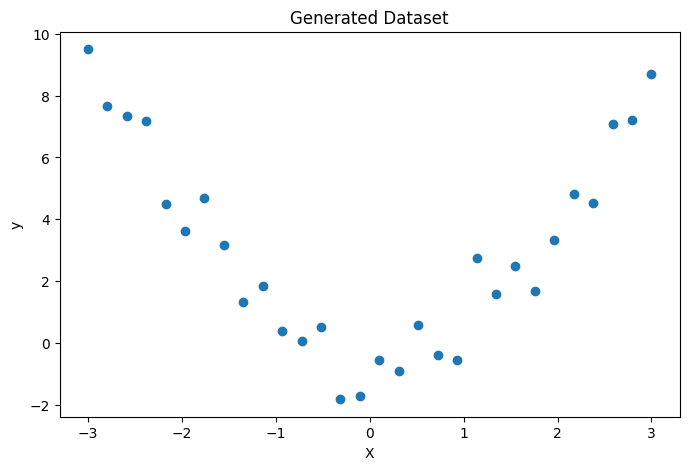

In [4]:
# Visualize the dataset

plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Dataset")

plt.show()

## 3. Train-Test Split

We divide the dataset into two parts:

### Training data

Used to train the model.

### Testing data

Used to evaluate how well the model performs on unseen data.

A model should not only perform well on the training data.

It should also perform well on the testing data.

In [5]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


# 4. Underfitting

Underfitting occurs when the model is too simple to learn the underlying pattern.

For our dataset, a simple Linear Regression model assumes:

y = mx + c

But our data approximately follows:

y = x²

Therefore, a straight-line model may not be complex enough.

In [6]:
# Create a simple Linear Regression model

linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

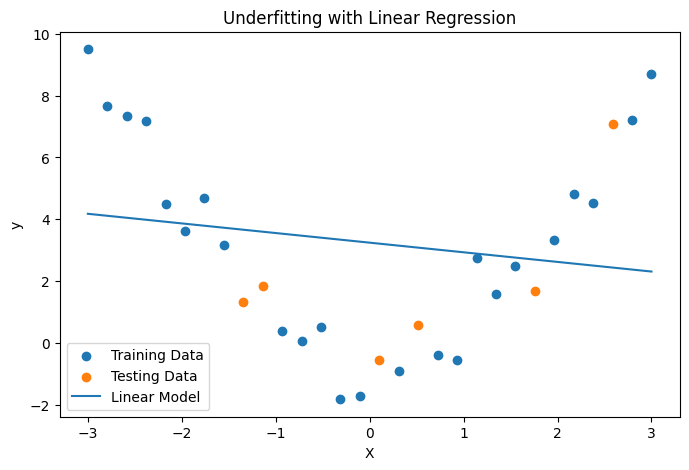

In [7]:
# Create points for drawing the regression line

X_curve = np.linspace(-3, 3, 200).reshape(-1, 1)
y_curve = linear_model.predict(X_curve)

# Plot the data and linear model

plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label="Training Data")
plt.scatter(X_test, y_test, label="Testing Data")

plt.plot(X_curve, y_curve, label="Linear Model")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Underfitting with Linear Regression")
plt.legend()

plt.show()

Interpretation

The straight line cannot properly capture the curved pattern.

Therefore, the model is underfitting.

##  Measure Underfitting

In [8]:
# Calculate training and testing errors

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training MSE:", train_mse)
print("Testing MSE :", test_mse)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)

Training MSE: 10.855496815562809
Testing MSE : 8.560500720685303
Training R²: 0.029850577713309567
Testing R² : -0.4784757132826363


### Underfitting Pattern

For an underfitted model:

- Training error → High
- Testing error → High
- Training performance → Poor
- Testing performance → Poor

The main problem is that the model is **too simple**.

# 5. Polynomial Regression

Polynomial Regression allows us to create more complex relationships.

For example:

### Degree 1

y = β₀ + β₁x

This is equivalent to Linear Regression.

### Degree 2

y = β₀ + β₁x + β₂x²

### Degree 3

y = β₀ + β₁x + β₂x² + β₃x³

Increasing the polynomial degree increases model complexity.

In [9]:
# Create a degree-2 polynomial regression model

degree_2_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

# Train the model
degree_2_model.fit(X_train, y_train)

# Predictions
y_train_pred_2 = degree_2_model.predict(X_train)
y_test_pred_2 = degree_2_model.predict(X_test)

## Visualize Good Fit

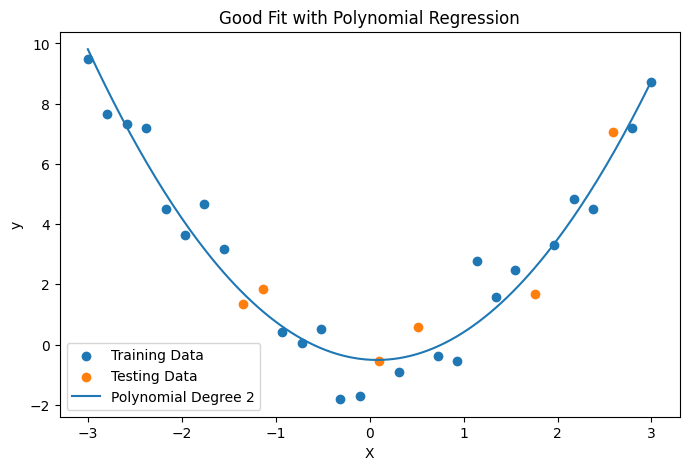

In [10]:
# Generate predictions for smooth curve

y_curve_2 = degree_2_model.predict(X_curve)

# Plot

plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label="Training Data")
plt.scatter(X_test, y_test, label="Testing Data")

plt.plot(X_curve, y_curve_2, label="Polynomial Degree 2")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Good Fit with Polynomial Regression")
plt.legend()

plt.show()

## Evaluate the Good Fit

In [11]:
# Calculate errors

train_mse_2 = mean_squared_error(y_train, y_train_pred_2)
test_mse_2 = mean_squared_error(y_test, y_test_pred_2)

train_r2_2 = r2_score(y_train, y_train_pred_2)
test_r2_2 = r2_score(y_test, y_test_pred_2)

print("Training MSE:", train_mse_2)
print("Testing MSE :", test_mse_2)

print("Training R²:", train_r2_2)
print("Testing R² :", test_r2_2)

Training MSE: 0.6747372250740824
Testing MSE : 0.46575499187893565
Training R²: 0.9396991275274942
Testing R² : 0.9195599105354632


### Good Fit

The degree-2 model is much better suited to our dataset.

The model captures the main curved pattern without becoming unnecessarily complicated.

A good model should have:

- Low training error
- Low testing error
- Small difference between training and testing performance
- Good generalization to unseen data

# 6. Overfitting

Now we will create a much more complex polynomial model.

A very high-degree polynomial has enough flexibility to follow almost every training point.

This sounds good because the training error may become extremely small.

However, the model may start learning:

- Noise
- Random fluctuations
- Unimportant details

instead of learning the general pattern.

This is called **overfitting**.

In [12]:
# Create a high-degree polynomial regression model

degree_15_model = make_pipeline(
    PolynomialFeatures(degree=15),
    LinearRegression()
)

# Train the model
degree_15_model.fit(X_train, y_train)

# Predictions
y_train_pred_15 = degree_15_model.predict(X_train)
y_test_pred_15 = degree_15_model.predict(X_test)

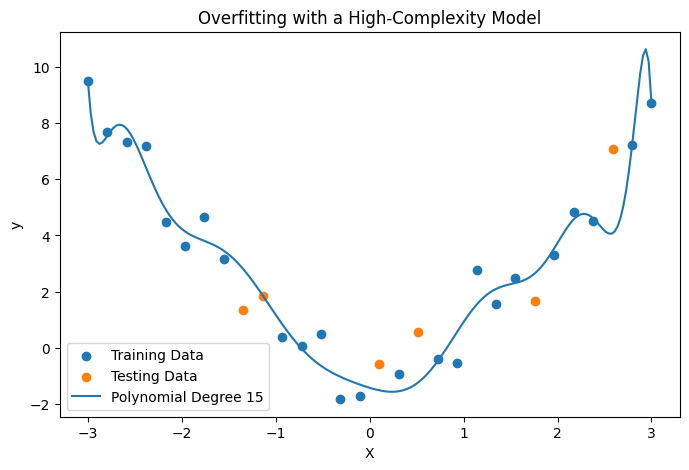

In [13]:
# Generate predictions for the smooth curve

y_curve_15 = degree_15_model.predict(X_curve)

# Plot

plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label="Training Data")
plt.scatter(X_test, y_test, label="Testing Data")

plt.plot(
    X_curve,
    y_curve_15,
    label="Polynomial Degree 15"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Overfitting with a High-Complexity Model")
plt.legend()

plt.show()

Interpretation

You should notice that the curve becomes much more complicated.

Instead of simply learning the overall U-shaped relationship, the model tries to follow individual data points.

That is the main idea behind overfitting.

## Evaluate Overfitting

In [14]:
# Calculate errors

train_mse_15 = mean_squared_error(y_train, y_train_pred_15)
test_mse_15 = mean_squared_error(y_test, y_test_pred_15)

train_r2_15 = r2_score(y_train, y_train_pred_15)
test_r2_15 = r2_score(y_test, y_test_pred_15)

print("Training MSE:", train_mse_15)
print("Testing MSE :", test_mse_15)

print("Training R²:", train_r2_15)
print("Testing R² :", test_r2_15)

Training MSE: 0.33331948145113866
Testing MSE : 2.6948628102984897
Training R²: 0.9702114322484875
Testing R² : 0.5345728777257843


### Overfitting Pattern

For an overfitted model:

- Training error → Very low
- Testing error → Relatively high
- Training performance → Very good
- Testing performance → Worse

The important warning sign is the **large gap between training and testing performance**.

The model has learned the training data too specifically and does not generalize well.

## Compare the Three Models

In [15]:
# Store the performance of all three models

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Degree 2",
        "Polynomial Degree 15"
    ],
    "Training MSE": [
        train_mse,
        train_mse_2,
        train_mse_15
    ],
    "Testing MSE": [
        test_mse,
        test_mse_2,
        test_mse_15
    ],
    "Training R²": [
        train_r2,
        train_r2_2,
        train_r2_15
    ],
    "Testing R²": [
        test_r2,
        test_r2_2,
        test_r2_15
    ]
})

results

,Model,Training MSE,Testing MSE,Training R²,Testing R²
0,Linear Regression,10.855497,8.560501,0.029851,-0.478476
1,Polynomial Degree 2,0.674737,0.465755,0.939699,0.919560
2,Polynomial Degree 15,0.333319,2.694863,0.970211,0.534573


### Comparing the Models

| Model | Complexity | Training Error | Testing Error | Problem |
|---|---|---|---|---|
| Linear Regression | Low | High | High | Underfitting |
| Polynomial Degree 2 | Moderate | Low | Low | Good Fit |
| Polynomial Degree 15 | High | Very Low | Higher | Overfitting |

The goal is not to minimize training error alone.

The goal is to build a model that **generalizes well to unseen data**.

# 7. Model Complexity

Model complexity describes how flexible a model is.

A simple model has limited flexibility.

A complex model can learn more complicated patterns.

For polynomial regression:

- Degree 1 → Low complexity
- Degree 2 → More complexity
- Degree 5 → Higher complexity
- Degree 15 → Very high complexity

As complexity increases:

Training error usually decreases.

However, testing error may first decrease and then increase.

This gives us an important idea:

> The best model is not necessarily the most complex model.

## Model Complexity Graph

In [16]:
# Test different polynomial degrees

degrees = range(1, 16)

train_errors = []
test_errors = []

for degree in degrees:
    
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    
    model.fit(X_train, y_train)
    
    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)
    
    train_errors.append(
        mean_squared_error(y_train, train_prediction)
    )
    
    test_errors.append(
        mean_squared_error(y_test, test_prediction)
    )

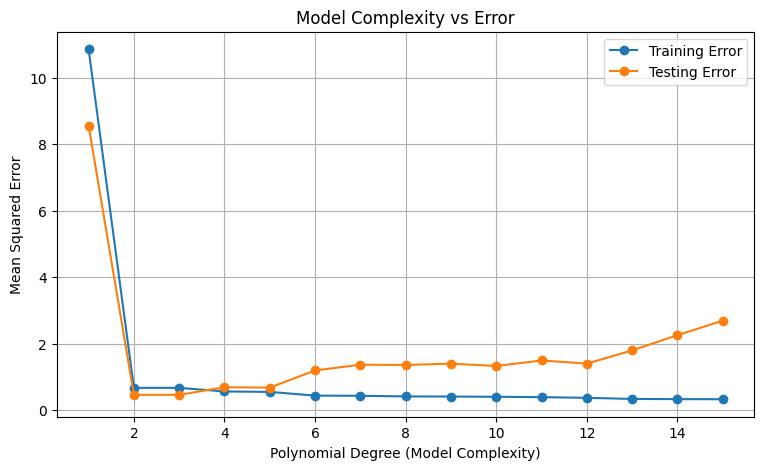

In [17]:
# Plot model complexity vs error

plt.figure(figsize=(9, 5))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Testing Error"
)

plt.xlabel("Polynomial Degree (Model Complexity)")
plt.ylabel("Mean Squared Error")
plt.title("Model Complexity vs Error")

plt.legend()
plt.grid(True)

plt.show()

### Understanding the Model Complexity Graph

At low model complexity:

- The model is too simple.
- Training error is high.
- Testing error is also high.
- This is **underfitting**.

As complexity increases:

- The model learns the underlying pattern.
- Training error decreases.
- Testing error also decreases.
- The model reaches a useful level of complexity.

If complexity becomes too high:

- Training error becomes very small.
- Testing error starts increasing.
- The model begins learning noise.
- This is **overfitting**.

Therefore, we want a model near the region where testing error is low.

## Visual Comparison of Underfitting, Good Fit and Overfitting

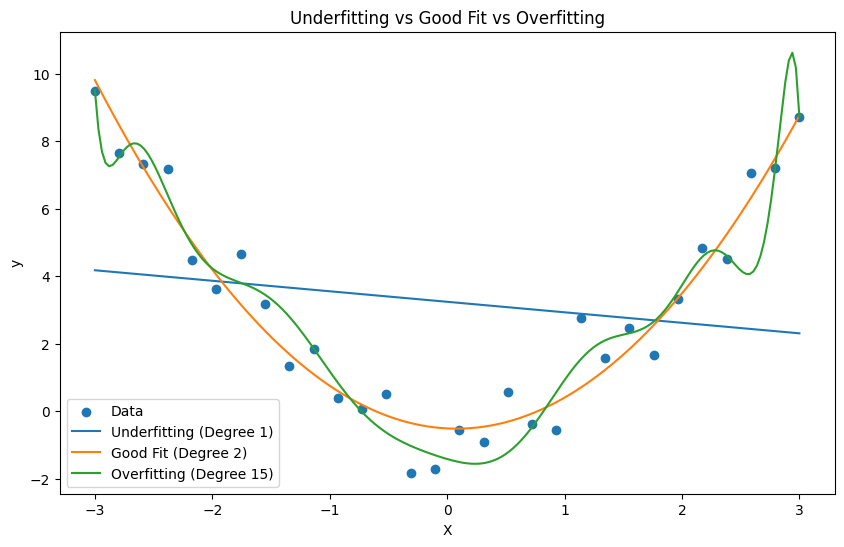

In [18]:
# Models with different complexities

models = {
    "Underfitting (Degree 1)": make_pipeline(
        PolynomialFeatures(degree=1),
        LinearRegression()
    ),
    
    "Good Fit (Degree 2)": make_pipeline(
        PolynomialFeatures(degree=2),
        LinearRegression()
    ),
    
    "Overfitting (Degree 15)": make_pipeline(
        PolynomialFeatures(degree=15),
        LinearRegression()
    )
}

plt.figure(figsize=(10, 6))

plt.scatter(X, y, label="Data")

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_curve)
    
    plt.plot(
        X_curve,
        predictions,
        label=name
    )

plt.xlabel("X")
plt.ylabel("y")
plt.title("Underfitting vs Good Fit vs Overfitting")
plt.legend()

plt.show()

# 8. How to Detect Overfitting and Underfitting

We can compare training and testing performance.

### Underfitting

Training performance → Poor  
Testing performance → Poor

The model has not learned enough.

### Good Fit

Training performance → Good  
Testing performance → Good

The model generalizes well.

### Overfitting

Training performance → Very good  
Testing performance → Poor

The model has learned the training data too specifically.

### Simple Rule

If both training and testing performance are poor:

→ Think about **underfitting**.

If training performance is excellent but testing performance is much worse:

→ Think about **overfitting**.

If both are good and reasonably close:

→ The model is likely generalizing well.

# 9. How to Reduce Overfitting

If a model is overfitting, we can try several approaches.

### 1. Reduce Model Complexity

Use a simpler model.

For polynomial regression, reduce the polynomial degree.

### 2. Use Regularization

Regularization adds a penalty for overly complex models.

Common methods include:

- Ridge Regression
- Lasso Regression

### 3. Use More Training Data

More representative training data can help the model learn the general pattern instead of memorizing individual examples.

### 4. Feature Selection

Remove unnecessary or irrelevant features.

### 5. Cross-Validation

Cross-validation provides a more reliable estimate of how well a model generalizes.

In this notebook, we will demonstrate regularization briefly.

## Ridge Regression

In [19]:
from sklearn.linear_model import Ridge

# Create a high-degree polynomial model with Ridge regularization

ridge_model = make_pipeline(
    PolynomialFeatures(degree=15),
    Ridge(alpha=10)
)

# Train the model
ridge_model.fit(X_train, y_train)

# Predictions
y_train_ridge = ridge_model.predict(X_train)
y_test_ridge = ridge_model.predict(X_test)

# Calculate errors
ridge_train_mse = mean_squared_error(y_train, y_train_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_ridge)

print("Ridge Training MSE:", ridge_train_mse)
print("Ridge Testing MSE :", ridge_test_mse)

Ridge Training MSE: 0.5494956258056211
Ridge Testing MSE : 1.373877529759083


## Regularized Model Visualization

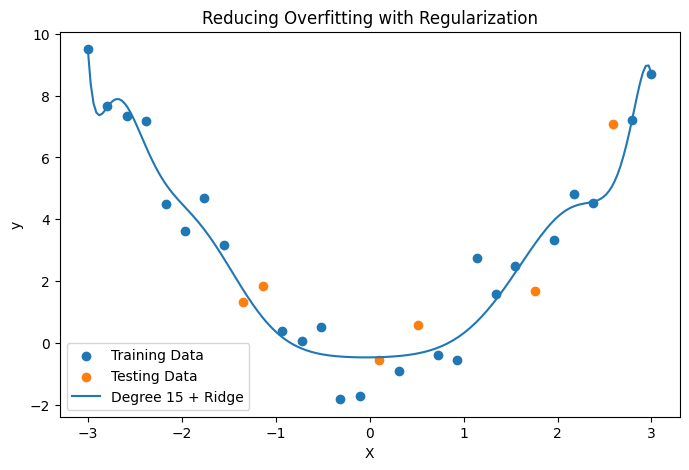

In [20]:
# Generate predictions for visualization

y_curve_ridge = ridge_model.predict(X_curve)

plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, label="Training Data")
plt.scatter(X_test, y_test, label="Testing Data")

plt.plot(
    X_curve,
    y_curve_ridge,
    label="Degree 15 + Ridge"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Reducing Overfitting with Regularization")
plt.legend()

plt.show()

# 10. Summary

## Underfitting

The model is too simple.

- High training error
- High testing error
- Cannot capture the important pattern

## Good Fit

The model captures the important pattern and generalizes well.

- Low training error
- Low testing error
- Small train-test performance gap

## Overfitting

The model is too complex.

- Very low training error
- Higher testing error
- Learns noise and specific details of training data

## Model Complexity

Increasing complexity can initially improve performance.

However, excessive complexity can cause overfitting.

## Important Principle

The goal of Machine Learning is not:

"Make training error as small as possible."

The goal is:

"Build a model that performs well on unseen data."

## Ways to Reduce Overfitting

- Reduce model complexity
- Use regularization
- Collect more representative data
- Remove unnecessary features
- Use cross-validation

#  Quick Revision

| Concept | Underfitting | Good Fit | Overfitting |
|---|---|---|---|
| Model Complexity | Too low | Appropriate | Too high |
| Training Error | High | Low | Very low |
| Testing Error | High | Low | High |
| Generalization | Poor | Good | Poor |
| Main Problem | Model too simple | — | Model too complex |
| Typical Solution | Increase complexity | Keep model | Reduce complexity / Regularize |

### Key Idea

A Machine Learning model should learn the **general pattern**, not memorize the training data.